<a href="https://colab.research.google.com/github/Teddy-2004/prob-bayesian-gradient-descent/blob/main/Formative_3_BVN_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1: BIVARIATE NORMAL DISTRIBUTION - MANUAL CALCULATION

STEP 1: COMPUTED PARAMETERS (CENTROID & SPREAD)
Mean Vector (μ): [5.0060, 3.4180]
Variance X: 0.1242, Variance Y: 0.1452
Covariance (xy): 0.1003
Correlation (ρ): 0.7468

STEP 2: MANUAL MATRIX INVERSION (PRECISION MATRIX)
Determinant |Σ|: 0.0080
Inverse Covariance Matrix (Σ⁻¹):
[[ 18.19581453 -12.57065845]
 [-12.57065845  15.57251512]]

STEP 3: PROBABILITY TOPOLOGY GENERATED
Grid Shape: (100, 100) (10,000 Density Points)
Max Density Value: 1.7811


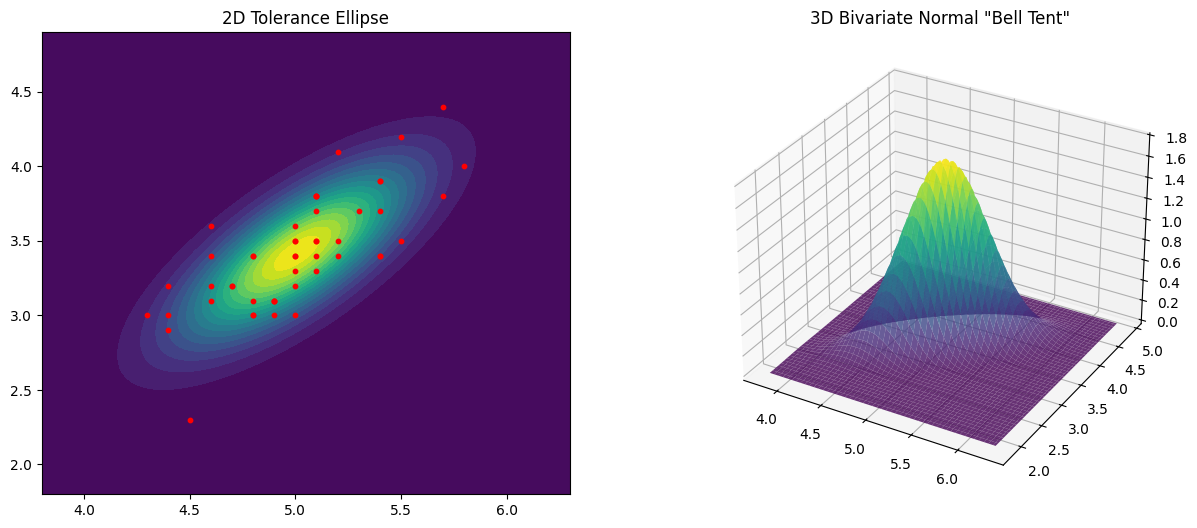

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 0: Data Sourcing
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv(url, names=cols)
df_setosa = df[df['species'] == 'Iris-setosa'].copy()

x = df_setosa["sepal_length"].values
y = df_setosa["sepal_width"].values
n = len(x)

print('='*70)
print('PART 1: BIVARIATE NORMAL DISTRIBUTION - MANUAL CALCULATION')
print('='*70)

# Step 1: STATISTICAL PARAMETERS
mu_x, mu_y = sum(x) / n, sum(y) / n
var_x = sum((x - mu_x)**2) / (n - 1)
var_y = sum((y - mu_y)**2) / (n - 1)
cov_xy = sum((x - mu_x) * (y - mu_y)) / (n - 1)
rho = cov_xy / (np.sqrt(var_x) * np.sqrt(var_y))

print('\n' + '='*70)
print('STEP 1: COMPUTED PARAMETERS (CENTROID & SPREAD)')
print('='*70)
print(f'Mean Vector (μ): [{mu_x:.4f}, {mu_y:.4f}]')
print(f'Variance X: {var_x:.4f}, Variance Y: {var_y:.4f}')
print(f'Covariance (xy): {cov_xy:.4f}')
print(f'Correlation (ρ): {rho:.4f}')

# Step 2: Matrix algebra
det_sigma = (var_x * var_y) - (cov_xy**2)
# Manual 2x2 Inverse Formula: (1/det) * [[d, -b], [-c, a]]
inv_sigma = (1 / det_sigma) * np.array([[var_y, -cov_xy], [-cov_xy, var_x]])

print('\n' + '='*70)
print('STEP 2: MANUAL MATRIX INVERSION (PRECISION MATRIX)')
print('='*70)
print(f'Determinant |Σ|: {det_sigma:.4f}')
print('Inverse Covariance Matrix (Σ⁻¹):')
print(inv_sigma)

# Step 3: PDF Calculation
def calculate_pdf(xi, yi, mu_x, mu_y, inv_sigma, det_sigma):
    diff = np.array([xi - mu_x, yi - mu_y])
    exponent = -0.5 * (diff.T @ inv_sigma @ diff)
    constant = 1 / (2 * np.pi * np.sqrt(det_sigma))
    return constant * np.exp(exponent)

# Generate Grid
x_grid = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.array([calculate_pdf(px, py, mu_x, mu_y, inv_sigma, det_sigma)
              for px, py in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

print('\n' + '='*70)
print('STEP 3: PROBABILITY TOPOLOGY GENERATED')
print('='*70)
print(f'Grid Shape: {Z.shape} (10,000 Density Points)')
print(f'Max Density Value: {np.max(Z):.4f}')
print('='*70)

# Step 4: Visualization
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
ax1.scatter(x, y, c='red', s=10, label='Actual Data')
ax1.set_title('2D Tolerance Ellipse')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax2.set_title('3D Bivariate Normal "Bell Tent"')
plt.show()